In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Bias vs. Variance

Компроміс зсуву та дисперсії
https://uk.wikipedia.org/wiki/%D0%9A%D0%BE%D0%BC%D0%BF%D1%80%D0%BE%D0%BC%D1%96%D1%81_%D0%B7%D1%81%D1%83%D0%B2%D1%83_%D1%82%D0%B0_%D0%B4%D0%B8%D1%81%D0%BF%D0%B5%D1%80%D1%81%D1%96%D1%97

### Model Complexity

Overfitting


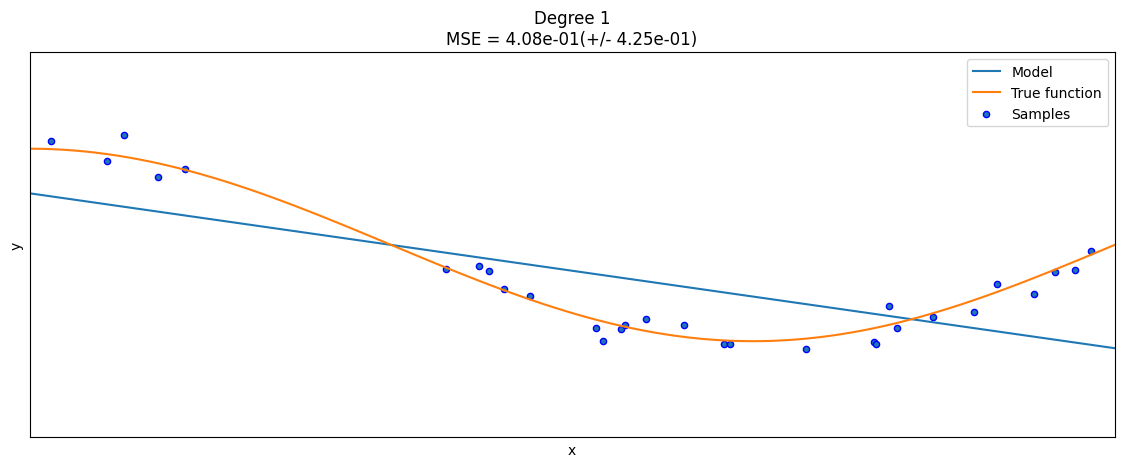

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1]#, 4]#, 15]

x = np.sort(np.random.rand(n_samples))
y = true_fun(x) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ('polynomial_features', polynomial_features),
            ('linear_refression', linear_regression)
        ]
    )
    pipeline.fit(x[:, np.newaxis], y)

    # Evalute the models using crossvalidation
    scores = cross_val_score(
        pipeline, x[:, np.newaxis], y, scoring='neg_mean_squared_error', cv=10
    )

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label='Model')
    plt.plot(X_test, true_fun(X_test), label='True function')
    plt.scatter(x, y, edgecolor='b', s=20, label='Samples')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc='best')
    plt.title(
        "Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
            degrees[i], -scores.mean(), scores.std()
        )
    )
plt.show()

#### Train-test split

In [3]:
df = pd.read_csv('train.csv')

meal_info_df = pd.read_csv('meal_info.csv')
meal_info_df = meal_info_df.reset_index(drop=False)

meal_info_df[['category', 'meal_id']].groupby(['category']).count()
df = df.merge(meal_info_df, on='meal_id', how='left')

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,index,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,1,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,2,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,26,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,4,Beverages,Indian


In [4]:
df.tail()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,index,category,cuisine
456543,1271326,145,61,1543,484.09,484.09,0,0,68,39,Desert,Indian
456544,1062036,145,61,2304,482.09,482.09,0,0,42,38,Desert,Indian
456545,1110849,145,61,2664,237.68,321.07,0,0,501,28,Salad,Italian
456546,1147725,145,61,2569,243.50,313.34,0,0,729,29,Salad,Italian
456547,1361984,145,61,2490,292.03,290.03,0,0,162,15,Salad,Italian


In [5]:
df.cuisine.unique()

array(['Thai', 'Indian', 'Italian', 'Continental'], dtype=object)

In [6]:
df_slice = df[(df['center_id'] == 55) & (df['cuisine'] == 'Thai')]
df_slice = df_slice[['checkout_price', 'num_orders']]

# sorted by checkout price
df_slice = df_slice.sort_values(by="checkout_price", axis=0, ascending=False)
df_slice.reset_index(inplace=True, drop=True)
df_slice

,checkout_price,num_orders
0,321.13,28
1,321.13,27
2,321.13,41
3,321.13,13
4,321.13,26
...,...,...
1274,80.54,54
1275,80.54,53
1276,80.54,55
1277,79.54,53


In [7]:
# train-test-split with skleran
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df_slice, shuffle=False, test_size=0.25)
train_data.head()

,checkout_price,num_orders
0,321.13,28
1,321.13,27
2,321.13,41
3,321.13,13
4,321.13,26


In [8]:
train_data.tail()

,checkout_price,num_orders
954,146.5,257
955,146.5,149
956,146.5,285
957,146.5,298
958,146.5,189


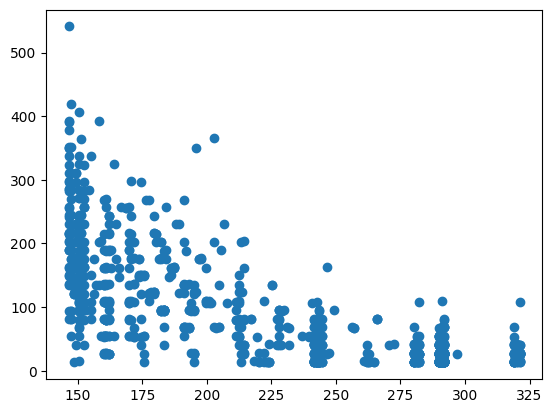

In [9]:
plt.scatter(train_data['checkout_price'], train_data['num_orders'])

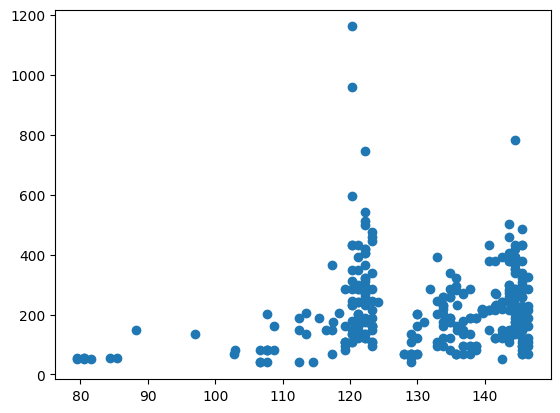

In [10]:
plt.scatter(test_data['checkout_price'], test_data['num_orders'])

In [11]:
from sklearn.linear_model import LinearRegression

x = train_data['checkout_price'].to_numpy().reshape(-1, 1)
y = train_data['num_orders'].to_numpy()

model = LinearRegression().fit(x, y)

In [12]:
train_data['predictions'] = model.predict(x)

x_test = test_data['checkout_price'].to_numpy().reshape(-1, 1)
test_data['predictions'] = model.predict(x_test)

<Axes: xlabel='checkout_price', ylabel='num_orders'>

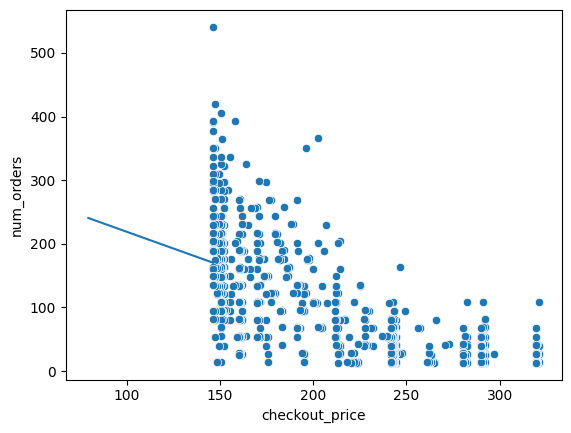

In [13]:
# Train
sns.scatterplot(x='checkout_price', y='num_orders', data=train_data)
sns.lineplot(data=test_data, x='checkout_price', y='predictions')

<Axes: xlabel='checkout_price', ylabel='num_orders'>

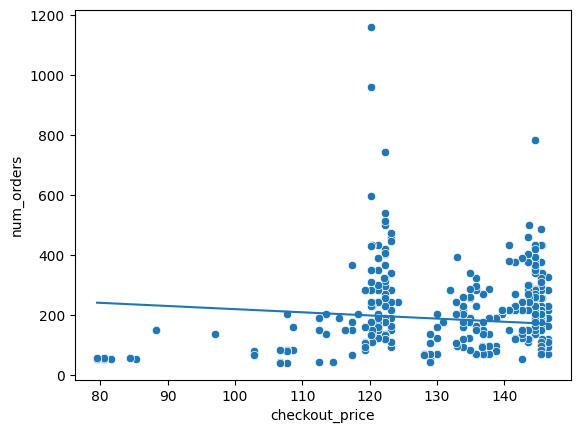

In [14]:
# Test
sns.scatterplot(x='checkout_price', y='num_orders', data=test_data)
sns.lineplot(data=test_data, x='checkout_price', y='predictions')

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error_train = mean_squared_error(train_data['num_orders'], train_data['predictions'])
print(f'Train {mean_squared_error_train=}')
mean_squared_error_test = mean_squared_error(test_data['num_orders'], test_data['predictions'])
print(f'Train {mean_squared_error_test=}')

Train mean_squared_error_train=3606.2784562593897
Train mean_squared_error_test=20230.47649416289


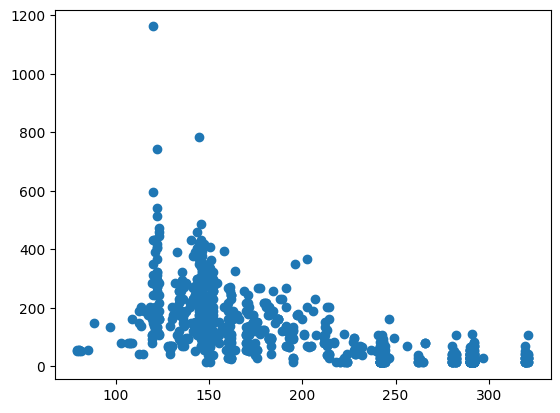

In [16]:
# Shuffle
train_data, test_data = train_test_split(df_slice, shuffle=True, test_size=0.25)
plt.scatter(train_data['checkout_price'], train_data['num_orders'])

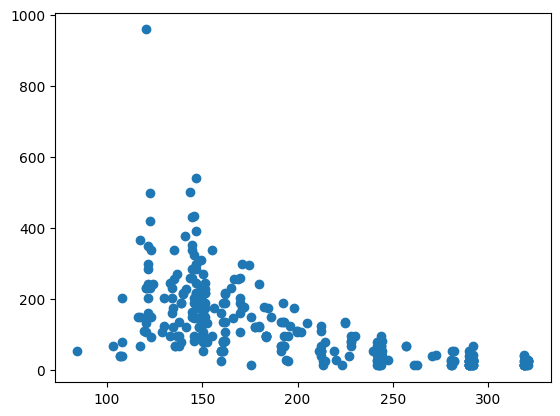

In [17]:
plt.scatter(test_data['checkout_price'], test_data['num_orders'])

In [18]:
x = train_data['checkout_price'].to_numpy().reshape(-1, 1)
y = train_data['num_orders'].to_numpy()

model = LinearRegression().fit(x, y)
train_data['predictions'] = model.predict(x)

x_test = test_data['checkout_price'].to_numpy().reshape(-1, 1)
test_data['predictions'] = model.predict(x_test)

<Axes: xlabel='checkout_price', ylabel='num_orders'>

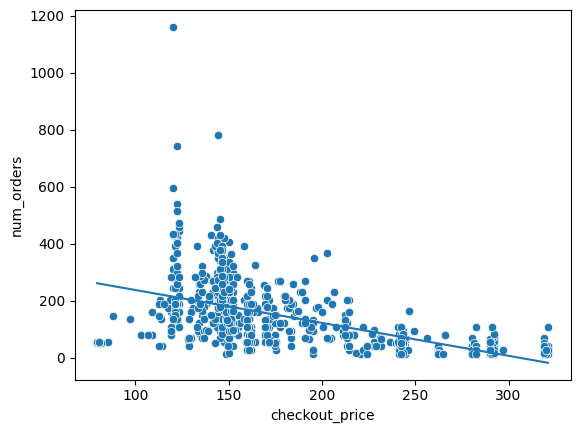

In [19]:
sns.scatterplot(x='checkout_price', y='num_orders', data=train_data)
sns.lineplot(data=train_data, x='checkout_price', y='predictions')

<Axes: xlabel='checkout_price', ylabel='num_orders'>

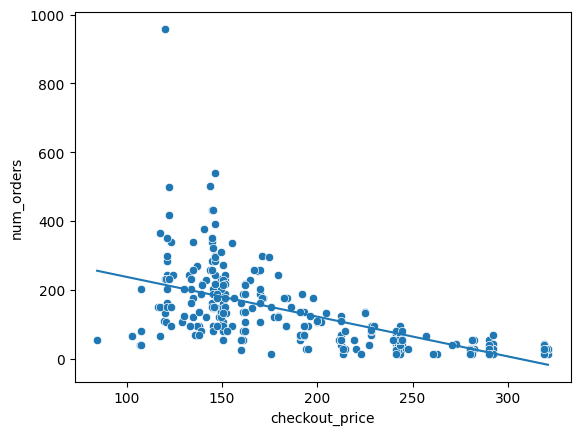

In [20]:
sns.scatterplot(x='checkout_price', y='num_orders', data=test_data)
sns.lineplot(data=test_data, x='checkout_price', y='predictions')

In [21]:
mean_squared_error_train = mean_squared_error(train_data['num_orders'], train_data['predictions'])
print(f'Train {mean_squared_error_train=}')
mean_squared_error_test = mean_squared_error(test_data['num_orders'], test_data['predictions'])
print(f'Train {mean_squared_error_test=}')

Train mean_squared_error_train=7731.297071028298
Train mean_squared_error_test=7484.561595717113


### Cross Validation

In [22]:
from sklearn import model_selection, datasets
import numpy as np
x = range(10)

In [23]:
kf = model_selection.KFold(n_splits=5)
for train_indices, test_index in kf.split(x):
    print(train_indices, test_index)

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [24]:
kf = model_selection.KFold(n_splits=2, shuffle=True)
for train_indices, test_index in kf.split(x):
    print(train_indices, test_index)

[0 1 3 5 8] [2 4 6 7 9]
[2 4 6 7 9] [0 1 3 5 8]


In [25]:
kf = model_selection.KFold(n_splits=2, shuffle=True, random_state=1)
for train_indices, test_index in kf.split(x):
    print(train_indices, test_index)

[1 3 5 7 8] [0 2 4 6 9]
[0 2 4 6 9] [1 3 5 7 8]


In [26]:
x = range(12)

In [27]:
y = np.array([0] * 6 + [1] * 6)
print(y)

skf = model_selection.StratifiedKFold(n_splits=2, shuffle=True, random_state=0)
for train_indices, test_index in skf.split(x, y):
    print(train_indices, test_index)

[0 0 0 0 0 0 1 1 1 1 1 1]
[ 0  3  5  7  8 11] [ 1  2  4  6  9 10]
[ 1  2  4  6  9 10] [ 0  3  5  7  8 11]


In [28]:
y = np.array([0, 1] * 6)
print(y)

skf = model_selection.StratifiedKFold(n_splits=2, shuffle=True, random_state=0)
for train_indices, test_index in skf.split(x, y):
    print(train_indices, test_index)

[0 1 0 1 0 1 0 1 0 1 0 1]
[ 0  3  5  6 10 11] [1 2 4 7 8 9]
[1 2 4 7 8 9] [ 0  3  5  6 10 11]


In [29]:
ss = model_selection.ShuffleSplit(n_splits=2, test_size=0.2)

for train_indices, test_index in ss.split(x):
    print(train_indices, test_index)

[ 6  5  8 11  4  1  0  7 10] [3 9 2]
[ 3 11  6  2  8  9  4  5 10] [0 1 7]


In [30]:
x = range(10)
target = np.array([0] * 5 + [1] * 5)
print(target)

sss = model_selection.StratifiedShuffleSplit(n_splits=4, test_size=0.2)
for train_indices, test_index in sss.split(x, target):
    print(train_indices, test_index)

[0 0 0 0 0 1 1 1 1 1]
[9 6 4 0 2 7 1 8] [3 5]
[6 7 1 8 0 2 4 9] [3 5]
[4 3 0 7 5 9 8 2] [1 6]
[9 6 7 3 0 1 8 4] [5 2]


In [31]:
loo = model_selection.LeaveOneOut()

for train_indices, test_index in loo.split(x):
    print(train_indices, test_index)

[1 2 3 4 5 6 7 8 9] [0]
[0 2 3 4 5 6 7 8 9] [1]
[0 1 3 4 5 6 7 8 9] [2]
[0 1 2 4 5 6 7 8 9] [3]
[0 1 2 3 5 6 7 8 9] [4]
[0 1 2 3 4 6 7 8 9] [5]
[0 1 2 3 4 5 7 8 9] [6]
[0 1 2 3 4 5 6 8 9] [7]
[0 1 2 3 4 5 6 7 9] [8]
[0 1 2 3 4 5 6 7 8] [9]


### Regularization

Lasso (L1) та Ridge (L2)

<Axes: xlabel='checkout_price', ylabel='num_orders'>

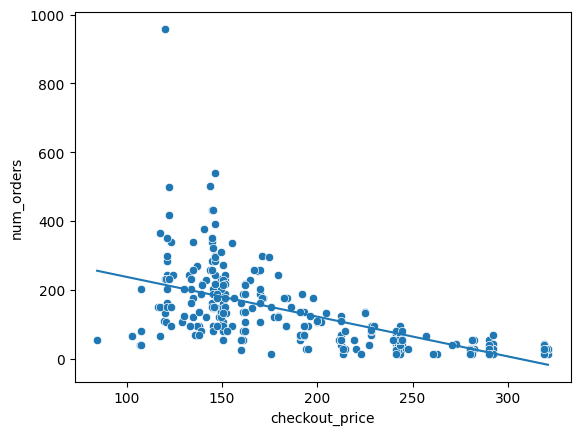

In [32]:
x = train_data['checkout_price'].to_numpy().reshape(-1, 1)
y = train_data['num_orders'].to_numpy()

model = LinearRegression().fit(x, y)
train_data['predictions'] = model.predict(x)

sns.scatterplot(x='checkout_price', y='num_orders', data=test_data)
sns.lineplot(data=test_data, x='checkout_price', y='predictions')


In [33]:
mean_squared_error_test = mean_squared_error(test_data['num_orders'], test_data['predictions'])
print(f'Train {mean_squared_error_test=}')

Train mean_squared_error_test=7484.561595717113


In [34]:
model.coef_

array([-1.15471077])

In [35]:
from copy import deepcopy

coefs = [-2.0, -1.7, -1.4, -1.16981158, -0.99, -0.98, -0.97, -0.84, -0.64, -0.5, -0.2, 0.01, 0.2, 0.45, 0.76, 0.99, 1.2]

models = []
for coef in coefs:
    new_model = deepcopy(model)
    new_model.coef_ = np.array([coef])
    models.append(new_model)

for i in range(len(models)):
    test_data[f'exp_{i}'] = models[i].predict(x_test)

<Axes: xlabel='checkout_price', ylabel='num_orders'>

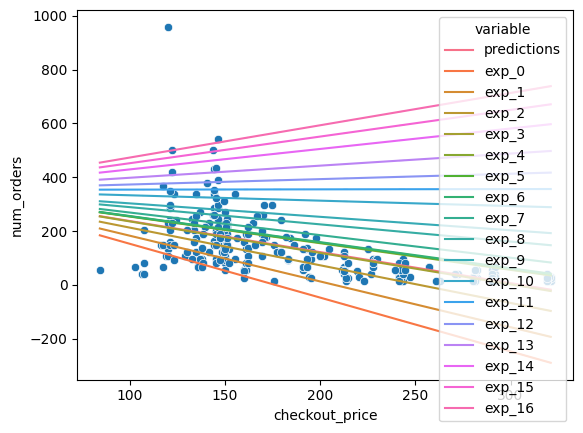

In [36]:
sns.scatterplot(x='checkout_price', y='num_orders', data=test_data)
sns.lineplot(x='checkout_price', y='value', hue='variable', data=pd.melt(test_data.drop(['num_orders'], axis=1), ['checkout_price']))

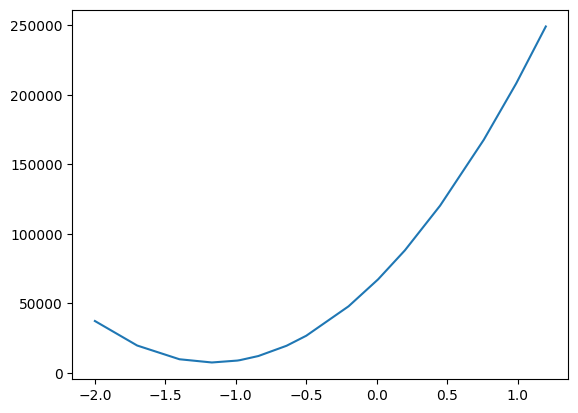

In [37]:
losses = []
for i, model in enumerate(models):
    losses.append(mean_squared_error(test_data['num_orders'], test_data[f'exp_{i}']))

plt.plot(np.array(coefs), np.array(losses), label='MSE')

<Axes: xlabel='checkout_price', ylabel='num_orders'>

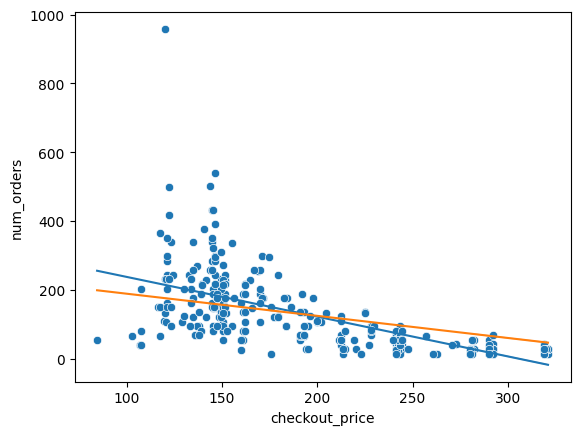

In [47]:
from sklearn.linear_model import Ridge, Lasso

models_lasso = Lasso(alpha=2000.0).fit(x, y)

test_data_lasso = test_data[:]

x_test = test_data_lasso['checkout_price'].to_numpy().reshape(-1, 1)
test_data_lasso['predictions'] = models_lasso.predict(x_test)

sns.scatterplot(x='checkout_price', y='num_orders', data=test_data_lasso)
sns.lineplot(data=test_data, x='checkout_price', y='predictions')
sns.lineplot(data=test_data_lasso, x='checkout_price', y='predictions')

In [48]:
mean_squared_error_test_lasso = mean_squared_error(test_data_lasso['num_orders'], test_data_lasso['predictions'])
print(f'Train {mean_squared_error_test_lasso=}')

Train mean_squared_error_test_lasso=8378.208557327254


In [50]:
coefs = [-2.0, -1.7, -1.4, -1.16981158, -0.99, -0.98, -0.97, -0.84, -0.64, -0.5, -0.2, 0.01, 0.2, 0.45, 0.76, 0.99, 1.2]

model_lasso = []
for coef in coefs:
    new_model = deepcopy(models_lasso)
    new_model.coef_ = np.array([coef])
    model_lasso.append(new_model)

for i in range(len(model_lasso)):
    test_data_lasso[f'exp_{i}'] = models_lasso.predict(x_test)

losses_lasso = []
for i, model in enumerate(model_lasso):
    losses_lasso.append(mean_squared_error(test_data_lasso['num_orders']), test_data_lasso[f'exp_{i}'])

plt.plot(np.array(coefs), np.array(losses), label='MSE')
plt.plot(np.array(coefs), np.array(losses_lasso), label='MSE')

TypeError: missing a required argument: 'y_pred'